# IPL Data Analysis (2008-2024)
This project performs an exploratory data analysis on the IPL dataset covering all matches and ball-by-ball data from 2008 to 2024. The dataset contains two files — matches.csv and deliveries.csv — merged on match ID to enable both match-level and player-level analysis. The analysis explores team dominance, toss impact, venue characteristics, player performance, and season-wise trends using Python, Pandas, Matplotlib, and Seaborn

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df1=pd.read_csv("matches.csv")
df2=pd.read_csv("deliveries.csv")

In [3]:
df1.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
df2.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
df=df1.merge(df2, how='inner', left_on='id', right_on='match_id')
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [6]:
print(df1.shape)
print(df2.shape)
print(df.shape)

(1095, 20)
(260920, 17)
(260920, 37)


In [7]:
df.isnull().sum()

id                       0
season                   0
city                 12397
date                     0
match_type               0
player_of_match        490
venue                    0
team1                    0
team2                    0
toss_winner              0
toss_decision            0
winner                 490
result                   0
result_margin         4124
target_runs            309
target_overs           309
super_over               0
method              257274
umpire1                  0
umpire2                  0
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
d

In [8]:
df.describe()

,id,result_margin,target_runs,target_overs,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,256796.000000,260611.000000,260611.000000,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,17.279451,167.290406,19.846742,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,21.600307,32.165944,1.224266,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,43.000000,5.000000,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,6.000000,148.000000,20.000000,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,8.000000,167.000000,20.000000,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,20.000000,188.000000,20.000000,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,146.000000,288.000000,20.000000,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 37 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                260920 non-null  int64  
 1   season            260920 non-null  object 
 2   city              248523 non-null  object 
 3   date              260920 non-null  object 
 4   match_type        260920 non-null  object 
 5   player_of_match   260430 non-null  object 
 6   venue             260920 non-null  object 
 7   team1             260920 non-null  object 
 8   team2             260920 non-null  object 
 9   toss_winner       260920 non-null  object 
 10  toss_decision     260920 non-null  object 
 11  winner            260430 non-null  object 
 12  result            260920 non-null  object 
 13  result_margin     256796 non-null  float64
 14  target_runs       260611 non-null  float64
 15  target_overs      260611 non-null  float64
 16  super_over        26

In [10]:
match_data=df[['id','season','team1','team2','toss_winner','toss_decision','winner','venue','city']].drop_duplicates(subset='id').copy()
match_data.shape

(1095, 9)

In [11]:
match_data['winner']=match_data['winner'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore','Delhi Capitals':'Delhi Daredevils','Rising Pune Supergiant':'Rising Pune Supergiants','Kings XI Punjab':'Punjab Kings'})
# merged duplicate team names

# Exploratory Data Analysis

## Q1.Which team has won most IPL matches?

In [12]:
wins=match_data.groupby('winner')[['id']].nunique().reset_index().sort_values('id',ascending=False).rename(columns={'id':'No. of wins'})
wins

,winner,No. of wins
8,Mumbai Indians,144
0,Chennai Super Kings,138
6,Kolkata Knight Riders,131
13,Royal Challengers Bangalore,123
2,Delhi Daredevils,115
10,Punjab Kings,112
11,Rajasthan Royals,112
14,Sunrisers Hyderabad,88
1,Deccan Chargers,29
4,Gujarat Titans,28


<Axes: xlabel='No. of wins', ylabel='winner'>

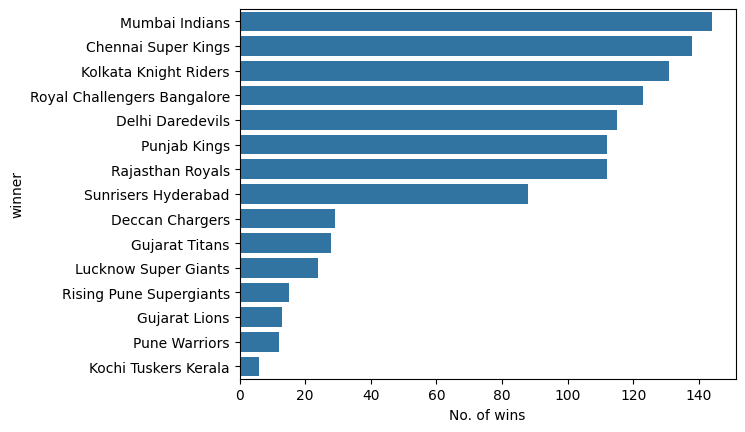

In [13]:
sns.barplot(data=wins,x='No. of wins',y='winner',orient='h')

### Insight:
- Mumbai Indians dominate all-time but they've also played the most seasons
- Wins alone is misleading — a team with 10 seasons will have more wins than one with 3
- Better metric: win rate (wins / matches played)

## Q2. Win rate of each team (Wins/Matches)

In [14]:
team1_count=match_data['team1'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore','Delhi Capitals':'Delhi Daredevils','Rising Pune Supergiant':'Rising Pune Supergiants','Kings XI Punjab':'Punjab Kings'}).value_counts()
team2_count=match_data['team2'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore','Delhi Capitals':'Delhi Daredevils','Rising Pune Supergiant':'Rising Pune Supergiants','Kings XI Punjab':'Punjab Kings'}).value_counts()
total_matches=(team1_count+team2_count).reset_index()

In [42]:
total_matches

,winner,No. of wins,index,count,win_rate
9,Gujarat Titans,28,Gujarat Titans,45,0.622222
1,Chennai Super Kings,138,Chennai Super Kings,238,0.579832
0,Mumbai Indians,144,Mumbai Indians,261,0.551724
10,Lucknow Super Giants,24,Lucknow Super Giants,44,0.545455
2,Kolkata Knight Riders,131,Kolkata Knight Riders,251,0.521912
6,Rajasthan Royals,112,Rajasthan Royals,221,0.506787
11,Rising Pune Supergiants,15,Rising Pune Supergiants,30,0.500000
7,Sunrisers Hyderabad,88,Sunrisers Hyderabad,182,0.483516
3,Royal Challengers Bangalore,123,Royal Challengers Bangalore,255,0.482353
4,Delhi Daredevils,115,Delhi Daredevils,252,0.456349


In [16]:
total_matches=wins.merge(total_matches,left_on='winner',right_on='index')

In [17]:
total_matches['win_rate'] = total_matches['No. of wins'] / total_matches['count']

In [18]:
total_matches=total_matches.sort_values('win_rate',ascending=False)

<Axes: xlabel='win_rate', ylabel='winner'>

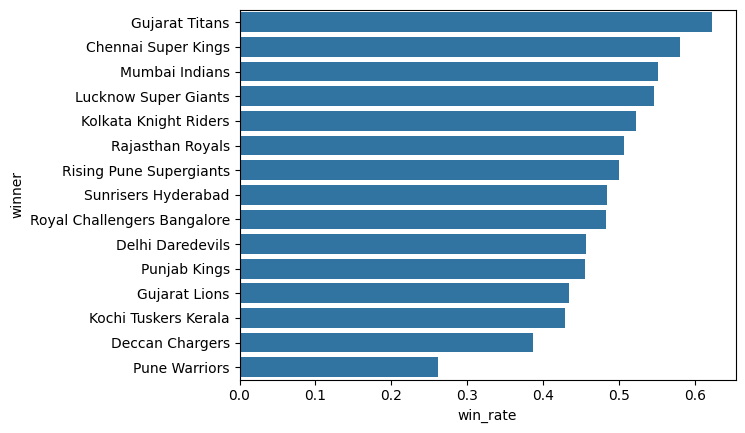

In [43]:
sns.barplot(data=total_matches,x='win_rate',y='winner',orient='h')

### Insight:
- Teams like Gujarat Titans have a high win rate despite fewer total wins 
- They're a newer franchise with fewer seasons. Mumbai Indians dominate raw wins but their win rate isn't the highest.
- Raw wins favors older teams. Win rate is fairer.

## Q3. Does winning the toss affect winning the match

In [20]:
match_data['toss_match_win']=match_data['toss_winner']==match_data['winner']

Text(0.5, 1.0, 'Does Winning the Toss Help?')

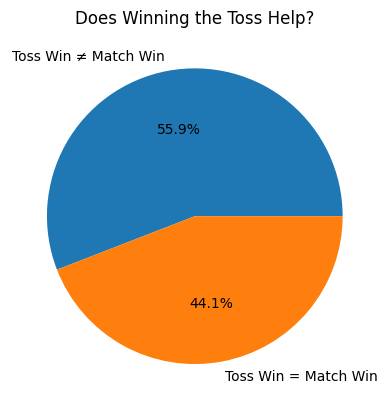

In [21]:
values=match_data['toss_match_win'].value_counts().values
plt.pie(values, labels=['Toss Win ≠ Match Win', 'Toss Win = Match Win'], 
        autopct='%1.1f%%')
plt.title('Does Winning the Toss Help?')

### Insight:
- Toss winner wins only 44% of matches
- Losing the toss actually correlates with winning more (56%)
- Conclusion: toss has no meaningful advantage — match outcome depends on team strength, not toss luck

## Q4. Which venues favor batting first?

In [22]:
match_data['bat_first_win']=match_data['team1']==match_data['winner']
match_data['venue'] = match_data['venue'].replace('M Chinnaswamy Stadium',"M.Chinnaswamy Stadium").str.split(',').str[0]

In [23]:
venue_stats = match_data.groupby('venue')['bat_first_win'].agg(['mean', 'count'])
venue_stats['mean'] = venue_stats['mean'] * 100
venue_stats = venue_stats[venue_stats['count'] > 15]
venue_stats = venue_stats.sort_values('mean', ascending=False).head(10)
# filtered venues with more than 15 matches

<Axes: xlabel='mean', ylabel='venue'>

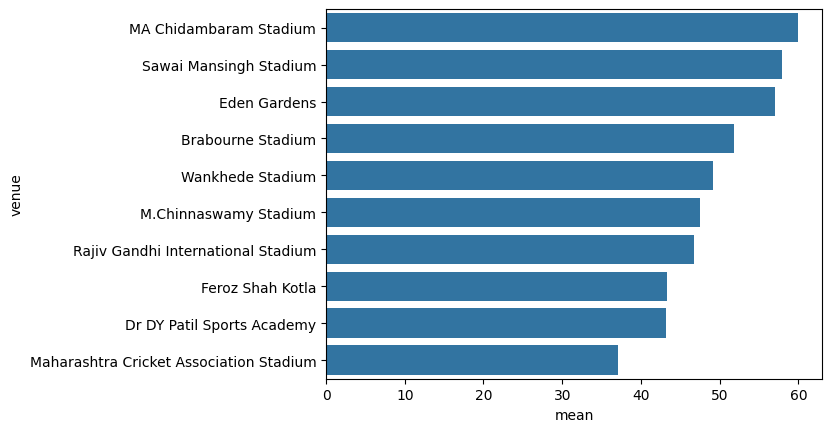

In [24]:
sns.barplot(data=venue_stats,x='mean',y='venue',orient='h')

### Insight:
- MA Chidambaram Stadium (Chennai) heavily favors batting first — 60%+ win rate. Slow, spin-friendly pitch helps teams set targets
- Sawai Mansingh Stadium (Jaipur) and Eden Gardens (Kolkata) also favor batting first
- Maharashtra Cricket Association Stadium (Pune) is the worst venue for batting first — teams prefer chasing there
- Most venues sit around 45-50% meaning pitch type alone doesn't decide outcome

## Q5. Who are the top 10 run scoreres in IPL history

In [25]:
runs=df2.groupby('batter')[['batsman_runs']].sum().reset_index().sort_values('batsman_runs',ascending=False).rename(columns={'batsman_runs':'Total runs'})
runs.head(10)

,batter,Total runs
631,V Kohli,8014
512,S Dhawan,6769
477,RG Sharma,6630
147,DA Warner,6567
546,SK Raina,5536
374,MS Dhoni,5243
30,AB de Villiers,5181
124,CH Gayle,4997
501,RV Uthappa,4954
282,KD Karthik,4843


<Axes: xlabel='Total runs', ylabel='batter'>

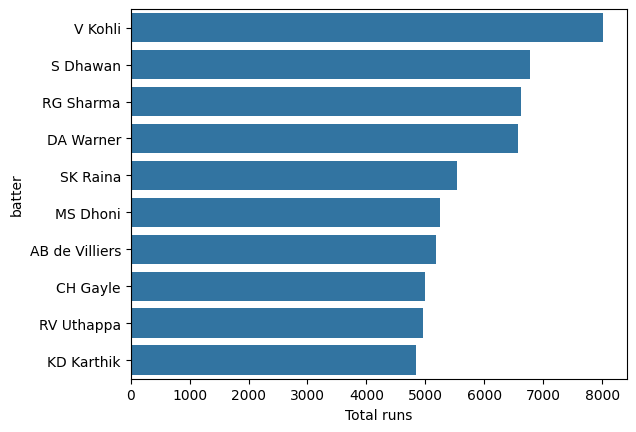

In [26]:
sns.barplot(data=runs.head(10),x='Total runs',y='batter',orient='h')

### Insight:
- Virat Kohli is the all-time leading run scorer with 8000+ runs — significant gap over 2nd place
- Top 4 are all openers (Kohli, Dhawan, Rohit, Warner) — opening position accumulates most runs
- MS Dhoni at 6th despite being a finisher who faces fewer balls — shows his consistency over 15+ seasons
- AB de Villiers and Gayle — overseas players who dominated despite playing fewer seasons than Indians

## Q6. Top 10 wicket takers in IPL history

In [27]:
wickets=df2.groupby('bowler')[['is_wicket']].sum().reset_index().sort_values('is_wicket',ascending=False).rename(columns={'is_wicket':'Total wickets'})
wickets.head(10)

,bowler,Total wickets
524,YS Chahal,213
119,DJ Bravo,207
348,PP Chawla,201
446,SP Narine,200
355,R Ashwin,198
71,B Kumar,195
438,SL Malinga,188
8,A Mishra,183
193,JJ Bumrah,182
373,RA Jadeja,169


<Axes: xlabel='Total wickets', ylabel='bowler'>

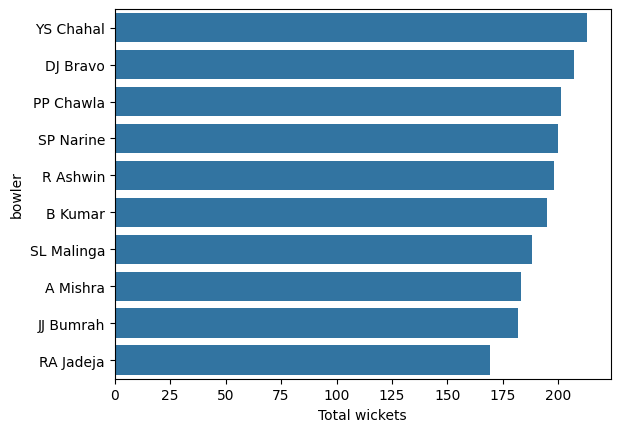

In [28]:
sns.barplot(data=wickets.head(10),x='Total wickets',y='bowler',orient='h')

### Insight:
- Yuzvendra Chahal leads with 213 wickets — spin dominates IPL conditions
- Spinners take 6 out of top 10 spots — slow pitches and short boundaries make spin more effective than pace
- DJ Bravo is the highest overseas wicket taker — his variations and death bowling made him lethal
- Bumrah at 9th despite missing multiple matches due to injury — his wickets per match ratio would be highest

## Q7. Which bowler has minimum economy rate (minimum 100 overs bowled)?

In [29]:
economy=df2.groupby('bowler')['total_runs'].agg(['sum','count'])
economy['overs']=np.round(economy['count']/6)
economy=economy[economy['overs']>100]
economy['economy']=economy['sum']/economy['overs']
economy=economy.sort_values('economy',ascending=True)
economy=economy.rename(columns={'sum':'Total runs','count':'Total balls'})
economy.head(10)

,Total runs,Total balls,overs,economy
bowler,,,,
A Kumble,1089,983,164.0,6.640244
M Muralitharan,1765,1581,264.0,6.685606
SP Narine,4672,4146,691.0,6.761216
DW Steyn,2583,2282,380.0,6.797368
DL Vettori,894,785,131.0,6.824427
Rashid Khan,3340,2901,484.0,6.900826
J Botha,818,709,118.0,6.932203
R Ashwin,5435,4679,780.0,6.967949
SL Malinga,3486,2974,496.0,7.028226


<Axes: xlabel='economy', ylabel='bowler'>

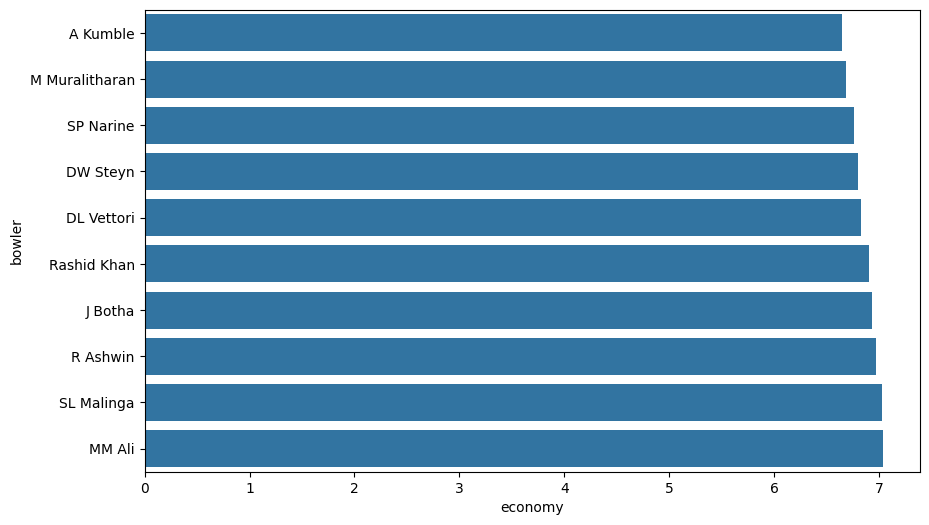

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(data=economy.head(10),x='economy',y='bowler',orient='h')

### Insight:
- Kumble and Muralitharan — legends from pre-T20 era, their classical spin was impossible to score off even in IPL
- Narine and Rashid Khan — mystery spinners, batters genuinely can't read their variations
- Steyn is the only genuine pace bowler in top 5 
- Malinga at 9th — surprising given his yorker reputation, but he leaked runs in middle overs
- R Ashwin at 8th — effective at home in Chennai but expensive away from spin-friendly pitches

## Q8. How has IPL scoring changed across seasons

In [31]:
df['season']=df['season'].replace({"2007/08":'2008','2009/10':'2010','2020/21':'2020'})
seasons=df.groupby('season')['total_runs'].sum().reset_index()
seasons

,season,total_runs
0,2008,17937
1,2009,16353
2,2010,18883
3,2011,21154
4,2012,22453
5,2013,22602
6,2014,18931
7,2015,18353
8,2016,18862
9,2017,18786


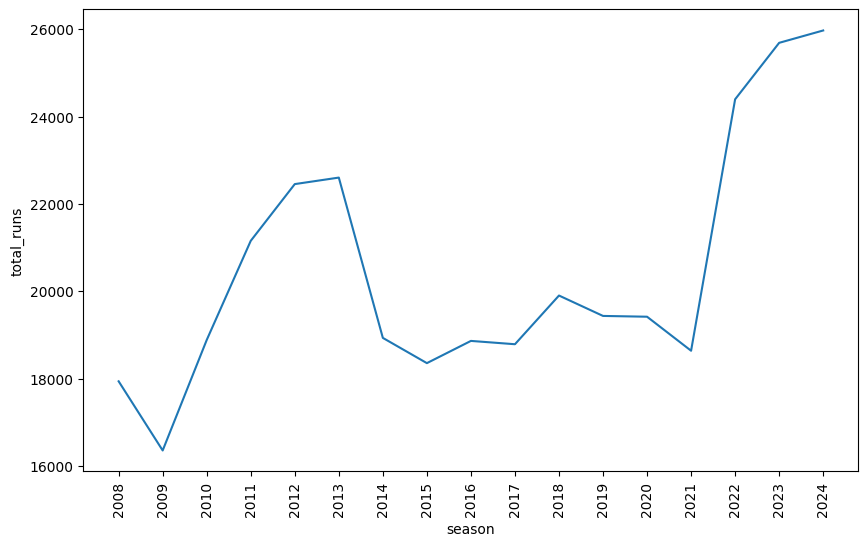

In [32]:
plt.figure(figsize=(10,6))
sns.lineplot(data=seasons,y='total_runs',x='season')
plt.xticks(rotation=90)
plt.show()

### Insight:
- Clear upward trend — IPL has become significantly more high-scoring over 16 years
- 2022-2024 are the highest scoring seasons — bat-friendly pitches, smaller boundaries, better batters
- 2009 dip — tournament was held in South Africa, unfamiliar conditions for batters
- 2014-2015 dip — pitches got slower, bowlers adapted to T20 cricket better
- 2022 spike — two new teams (GT and LSG) added, more matches played, also batting evolved significantly
- Overall conclusion: modern IPL is 40%+ more high-scoring than early seasons

## Q9. Team v/s Team head to head record 

In [33]:
match_data['team1']=match_data['team1'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore','Delhi Capitals':'Delhi Daredevils','Rising Pune Supergiant':'Rising Pune Supergiants','Kings XI Punjab':'Punjab Kings'})
match_data['team2']=match_data['team2'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore','Delhi Capitals':'Delhi Daredevils','Rising Pune Supergiant':'Rising Pune Supergiants','Kings XI Punjab':'Punjab Kings'})
match_data['lost_team']=np.where(match_data['winner'] == match_data['team1'], match_data['team2'], match_data['team1'])
pivot=pd.pivot_table(match_data, values='id', index='winner', columns='lost_team', aggfunc='count')
pivot

lost_team,Chennai Super Kings,Deccan Chargers,Delhi Daredevils,Gujarat Lions,Gujarat Titans,Kochi Tuskers Kerala,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,Pune Warriors,Punjab Kings,Rajasthan Royals,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
winner,,,,,,,,,,,,,,,
Chennai Super Kings,NaN,6.0,19.0,NaN,3.0,1.0,19.0,1.0,17.0,4.0,16.0,16.0,NaN,21.0,15.0
Deccan Chargers,4.0,NaN,4.0,NaN,NaN,1.0,2.0,NaN,4.0,3.0,3.0,2.0,NaN,6.0,NaN
Delhi Daredevils,11.0,7.0,NaN,3.0,3.0,1.0,15.0,2.0,16.0,3.0,16.0,14.0,2.0,11.0,11.0
Gujarat Lions,NaN,NaN,1.0,NaN,NaN,NaN,3.0,NaN,2.0,NaN,2.0,NaN,3.0,2.0,NaN
Gujarat Titans,4.0,NaN,2.0,NaN,NaN,NaN,2.0,4.0,3.0,NaN,3.0,5.0,NaN,2.0,3.0
Kochi Tuskers Kerala,1.0,NaN,1.0,NaN,NaN,NaN,2.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN
Kolkata Knight Riders,10.0,7.0,18.0,1.0,1.0,NaN,NaN,2.0,11.0,4.0,21.0,14.0,3.0,20.0,19.0
Lucknow Super Giants,3.0,NaN,3.0,NaN,1.0,NaN,3.0,NaN,5.0,NaN,3.0,1.0,NaN,2.0,3.0
Mumbai Indians,20.0,6.0,19.0,2.0,2.0,NaN,23.0,1.0,NaN,5.0,17.0,15.0,2.0,19.0,13.0


<Axes: xlabel='lost_team', ylabel='winner'>

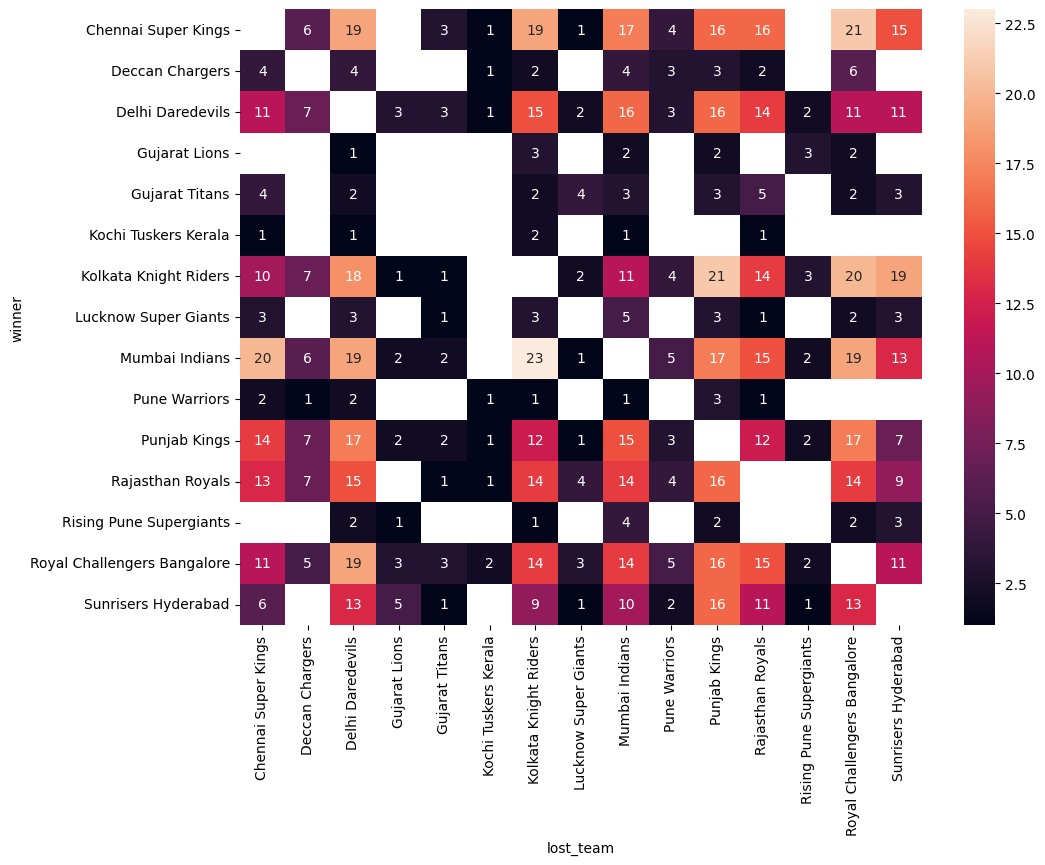

In [34]:
plt.figure(figsize=(11,8))
sns.heatmap(pivot, annot=True, fmt='.0f')

### Insight:
- Mumbai Indians beat KKR 23 times — most dominant single rivalry in IPL history
- CSK beat RCB 21 times and KKR 19 times — CSK dominates both their biggest rivals
- RCB despite being a top franchise has losing records against almost everyone — explains why they never won a title
- Delhi Daredevils have played a lot but their numbers are mediocre across all rivalries
- Newer teams (Gujarat Titans, Lucknow) have sparse data — too few seasons to establish rivalries
- MI and CSK have the highest row totals — most wins against most teams, the two true dynasties of IPL

## Q10. Season wise team performance?

In [35]:
wins_per_season = match_data.groupby(['season', 'winner'])['id'].count().reset_index()
wins_per_season.rename(columns={'id': 'wins'}, inplace=True)
wins_per_season.rename(columns={'winner': 'team'}, inplace=True)
wins_per_season.sample(2)

,season,team,wins
18,2009/10,Delhi Daredevils,7
41,2012,Rajasthan Royals,7


In [36]:
team1_season = match_data.groupby(['season', 'team1'])['id'].count().reset_index()
team2_season = match_data.groupby(['season', 'team2'])['id'].count().reset_index()
team1_season.rename(columns={'team1': 'team', 'id': 'matches'}, inplace=True)
team2_season.rename(columns={'team2': 'team', 'id': 'matches'}, inplace=True)
total_season = pd.concat([team1_season, team2_season]).groupby(['season', 'team'])['matches'].sum().reset_index()
total_season.sample(2)

,season,team,matches
135,2023,Sunrisers Hyderabad,14
74,2016,Royal Challengers Bangalore,16


In [37]:
total_season=total_season.merge(wins_per_season,on=['season','team'])
total_season

,season,team,matches,wins
0,2007/08,Chennai Super Kings,16,9
1,2007/08,Deccan Chargers,14,2
2,2007/08,Delhi Daredevils,14,7
3,2007/08,Kolkata Knight Riders,13,6
4,2007/08,Mumbai Indians,14,7
...,...,...,...,...
141,2024,Mumbai Indians,14,4
142,2024,Punjab Kings,14,5
143,2024,Rajasthan Royals,15,9
144,2024,Royal Challengers Bangalore,15,7


In [38]:
total_season['win_rate_season']=total_season['wins']/total_season['matches']

In [39]:
pivot_table=total_season.pivot_table(values='win_rate_season',index='team',columns='season')
pivot_table

season,2007/08,2009,2009/10,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020/21,2021,2022,2023,2024
team,,,,,,,,,,,,,,,,,
Chennai Super Kings,0.562500,0.571429,0.562500,0.687500,0.555556,0.666667,0.625000,0.588235,NaN,NaN,0.687500,0.588235,0.428571,0.687500,0.285714,0.625000,0.500000
Deccan Chargers,0.142857,0.562500,0.500000,0.428571,0.266667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delhi Daredevils,0.500000,0.666667,0.500000,0.285714,0.611111,0.187500,0.142857,0.357143,0.500000,0.428571,0.357143,0.625000,0.529412,0.625000,0.500000,0.357143,0.500000
Gujarat Lions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.562500,0.285714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gujarat Titans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.750000,0.647059,0.416667
Kochi Tuskers Kerala,NaN,NaN,NaN,0.428571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Kolkata Knight Riders,0.461538,0.230769,0.500000,0.533333,0.705882,0.375000,0.687500,0.538462,0.533333,0.562500,0.562500,0.428571,0.500000,0.529412,0.428571,0.428571,0.785714
Lucknow Super Giants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.600000,0.533333,0.500000
Mumbai Indians,0.500000,0.384615,0.687500,0.625000,0.588235,0.684211,0.466667,0.625000,0.500000,0.705882,0.428571,0.687500,0.687500,0.500000,0.285714,0.562500,0.285714


<Axes: xlabel='season', ylabel='team'>

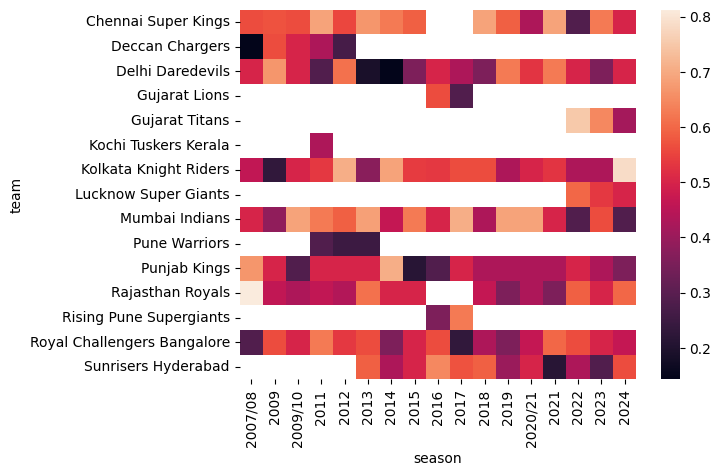

In [40]:
sns.heatmap(pivot_table)

### Insight:
- Gujarat Titans are the most consistent new franchise — 0.75 win rate in debut 2022, strong ever since
- CSK is the most consistent team across all seasons — rarely drops below 0.55, dark purple throughout
- Mumbai Indians won 5 titles but their performance is inconsistent season to season — feast or famine
- Punjab Kings have been consistently mediocre — never a standout season in 17 year
- Sunrisers Hyderabad peaked 2016-2018 then collapsed — one-era dominance
- NaN cells tell the story of franchise discontinuation — Deccan Chargers, Pune Warriors, Kochi Tuskers all had short runs